# Explore data from app DB

In [15]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
df = pd.read_csv('../data/car_pricing_model/raw/cars_listing.csv')
features = ["price","make","model","year","body_type","fuel_type","engine_volume","mileage","engine_cylinders","transmission","drivetrain","color"]
feature_built = ["car_age","Engine Displacement","Miles per year"]
df = df[features]

In [17]:
df = df[(df['price'] > 500) & (df['price'] < 500000)]
df = df[(df['year'] > 1970) & (df['year'] < 2028)]
df = df[(df['mileage'] > 1) & (df['mileage'] < 500000)]
df = df[(df['engine_volume'] >= 1) & (df['engine_volume'] < 7)]
df = df[(df['engine_cylinders'] >= 3) & (df['engine_cylinders'] < 17)]

len(df)

5

In [18]:
# if 4 or more values are NaN drop the row
df = df[df.isna().sum(axis=1) < 4]
len(df)

4

In [19]:
df.head()

,price,make,model,year,body_type,fuel_type,engine_volume,mileage,engine_cylinders,transmission,drivetrain,color
0,29753,Mazda,CX-90,2024,SUV,Petrol,3.3,72420,6,Automatic,4WD,Red
1,29753,Mazda,CX-90,2024,SUV,Petrol,3.3,72415,6,Automatic,4WD,Red
2,33000,Jeep,Wrangler,2026,SUV,Petrol,3.6,1609,6,Automatic,4WD,Red
3,19643,Toyota,Camry,2022,Sedan,Petrol,2.5,128747,4,Automatic,NaN,NaN


In [20]:
df['price'].describe()

count        4.00000
mean     28037.25000
std       5801.72149
min      19643.00000
25%      27225.50000
50%      29753.00000
75%      30564.75000
max      33000.00000
Name: price, dtype: float64

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

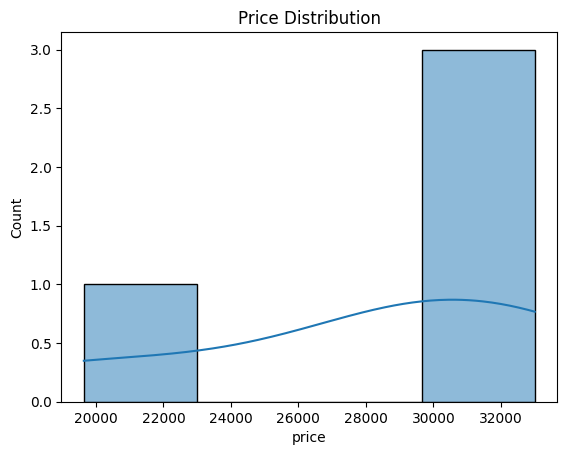

In [22]:
sns.histplot(df['price'], kde=True)
plt.title('Price Distribution')
plt.show()

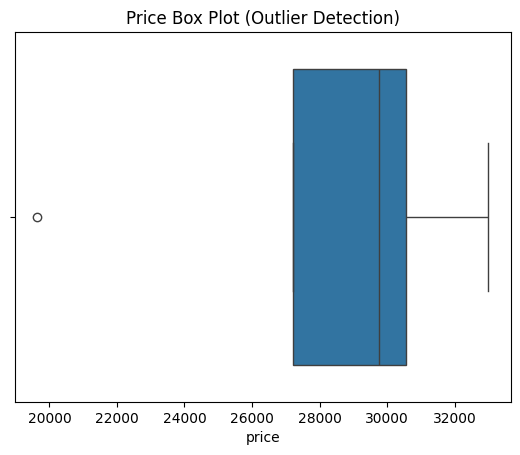

In [23]:
sns.boxplot(x=df['price'])
plt.title('Price Box Plot (Outlier Detection)')
plt.show()

In [24]:
df['price'].skew()

np.float64(-1.5674771879609481)

In [25]:
from scipy import stats

# Box-COx requires all values to be strictly positive (> 0)
fitted_data, fitted_lambda = stats.boxcox(df['price'])

print(pd.Series(fitted_data).skew())

-0.7242974552942806


In [27]:
df.head(100)

,price,make,model,year,body_type,fuel_type,engine_volume,mileage,engine_cylinders,transmission,drivetrain,color
0,29753,Mazda,CX-90,2024,SUV,Petrol,3.3,72420,6,Automatic,4WD,Red
1,29753,Mazda,CX-90,2024,SUV,Petrol,3.3,72415,6,Automatic,4WD,Red
2,33000,Jeep,Wrangler,2026,SUV,Petrol,3.6,1609,6,Automatic,4WD,Red
3,19643,Toyota,Camry,2022,Sedan,Petrol,2.5,128747,4,Automatic,NaN,NaN
